In [100]:
import pandas

import pygsheets
import numpy
import scipy
import re

import matplotlib
import matplotlib.pyplot as mp
import matplotlib.cm
import matplotlib.patheffects # for adding borders around text

import textwrap
#import seaborn
#import squarify

#import ttf_opensans

# gemplot variables

In [101]:
footer_color = "#222222"
footer_lineheight = 1.2
footer_fontsize = 14

# default height of a figure is 450 pixels

# gemstyle does this:
# specify a base_ratio, then set base_size = base_ratio*16
# 1. add 6 line margin all the way around
# 2. color of title is "#222222", margin 6666, size=base_size*1.5, lineheight=1.35, bold font
# 3. color of subtitle is "#333333", margin 0666, padding top=12, bottom=12, size=base_size*1.15, lineheight=1.45
# 4. set caption info as linehight=1.2, size=base_size*0.875, color="#222222", margin=18,6,6,6

base_ratio = 1.0
base_size = base_ratio * 16
color_title = "#222222"
color_subtitle = "#333333"
color_grid = "#cbcbcb"

text_weight_normal = 400
text_weight_bold = 700

# save fig
#' @keywords save_gem_plot
#' @examples
#' save_gem_plot(
#' plot_grid = line_plot_with_gem_footer,
#' save_filepath = "filename_that_my_plot_should_be_saved_to-nc.png",
#' width_pixels = 770,
#' height_pixels = 540,
#' resolution = 4
#' )
#'
#' @export
# save plot function - now separated from finalise_plot function and setting the resolution as part of the arguments
# save_gem_plot <- function (plot_grid, save_filepath, width_pixels = 640, height_pixels = 450, resolution = 3) {
#   grid::grid.draw(plot_grid)

#   #save it
#   ggplot2::ggsave(plot=plot_grid,
#                   width= (width_pixels/72),
#                   height= (height_pixels/72),
#                   dpi = resolution * 100,
#                   filename = save_filepath,
#                   bg="white")
# }

#width_pixels = 640 # default
#height_pixels = 450 # default

## define colors used in bars

In [102]:
# sel_cmap = matplotlib.colormaps['Reds']
# tracker_operating = sel_cmap(0.999)
# tracker_construction = sel_cmap(0.8)
# tracker_proposed = sel_cmap(0.6)
# tracker_shelved = sel_cmap(0.4)
# tracker_cancelled = sel_cmap(0.2)

tracker_construction = '#761200'
tracker_proposed = '#bf532c'
tracker_shelved = '#e3710c'
#tracker_cancelled = '#357a5d'
#tracker_cancelled = '#4e8a71'
tracker_cancelled = '#9abcae'

# import data directly from google sheets

In [103]:
gc = pygsheets.authorize(service_account_env_var='GDRIVE_API_CREDENTIALS')
#spreadsheet = gc.open_by_key('1WaBMIdfRWqSqXUw7_cKXo3RipyhPdnNN8flqEYfMZIA') # dec 2023 data release
#spreadsheet = gc.open_by_key('1foPLE6K-uqFlaYgLPAUxzeXfDO5wOOqE7tibNHeqTek') # CURRENT sheet
#spreadsheet = gc.open_by_key('1OXybaZOn0f2ONB6d_J0A3SG2bJ660C2Kr8fuc5o8cjs') # dec 2024 dataset for GGIT release
spreadsheet = gc.open_by_key('1xjaeq0OwdN-Orht7Q7ynPHB2uY_gnMvAeha-QHkzoZw') # Nov 2025 for GGIT

gas_pipes = spreadsheet.worksheet('title','Gas pipelines').get_as_df(start='A3')
oil_pipes = spreadsheet.worksheet('title', 'Oil/NGL pipelines').get_as_df(start='A3')

pipes_df_orig = pandas.concat([gas_pipes, oil_pipes], ignore_index=True)
pipes_df_orig = pipes_df_orig.loc[pipes_df_orig.Fuel.isin(['Gas','Gas and Hydrogen'])]
hydro_mask = pipes_df_orig.Fuel=='Gas and Hydrogen'
pipes_df_orig.loc[hydro_mask, 'Fuel'] = 'Gas'

#get country ratios sheet
country_ratios_df = spreadsheet.worksheet('title', 'Country ratios by pipeline').get_as_df()
region_df_orig = spreadsheet.worksheet('title', 'Country dictionary').get_as_df(start='A2')

In [104]:
status_list = ['proposed', 
               'construction', 
               'shelved', 
               'cancelled', 
               'operating', 
               'idle', 
               'mothballed', 
               'retired']
country_list = sorted(set(region_df_orig['Country'].tolist()))
region_list = sorted(set(region_df_orig['Region'].tolist()))
if '--' in region_list:
    region_list.remove('--')
subregion_list = sorted(set(region_df_orig['SubRegion'].tolist()))
if '--' in subregion_list:
    subregion_list.remove('--')

#country_list = sorted(list(set(terms_df_orig['Country'])))
#region_list = sorted(list(set(terms_df_orig['Region'])))

## replace "--" with NaN, removing empty rows

the dataset is structured to have -- wherever there's a lookup value that doesn't exist; replacing it with NaN (numpy.nan) allows pandas to treat it as a null value, which makes calculations much easier

In [105]:
# replace -- entries with NaN
pipes_df_orig = pipes_df_orig.replace('--', numpy.nan)
pipes_df_orig = pipes_df_orig[pipes_df_orig['PipelineName']!='']

missing_wiki_projectids = pipes_df_orig.loc[pipes_df_orig.Wiki==''].ProjectID.tolist()
pipes_df_orig = pipes_df_orig[pipes_df_orig['Wiki']!='']

country_ratios_df.replace('--', numpy.nan, inplace=True)
country_ratios_df = country_ratios_df.loc[~country_ratios_df.ProjectID.isin(missing_wiki_projectids)]

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_87296/1850051164.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pipes_df_orig = pipes_df_orig.replace('--', numpy.nan)
/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_87296/1850051164.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  country_ratios_df.replace('--', numpy.nan, inplace=True)


# km by country, km by region calculations

In [106]:
dict_subregion_region = pandas.Series(region_df_orig.Region.values, index=region_df_orig.SubRegion).to_dict()
dict_subregion_region

{'--': '--',
 'Northern Africa': 'Africa',
 'Sub-Saharan Africa': 'Africa',
 'Latin America and the Caribbean': 'Americas',
 'Northern America': 'Americas',
 'Central Asia': 'Asia',
 'Eastern Asia': 'Asia',
 'South-eastern Asia': 'Asia',
 'Southern Asia': 'Asia',
 'Western Asia': 'Asia',
 'Eastern Europe': 'Europe',
 'Northern Europe': 'Europe',
 'Southern Europe': 'Europe',
 'Western Europe': 'Europe',
 'Australia and New Zealand': 'Oceania',
 'Melanesia': 'Oceania',
 'Micronesia': 'Oceania',
 'Polynesia': 'Oceania'}

In [107]:
region_df_orig_cleaned = region_df_orig.loc[(region_df_orig.Region!='--')&
                                            (region_df_orig.SubRegion!='--')]
multiindex_region_subregion = region_df_orig_cleaned.groupby(['Region','SubRegion'])['Country'].count().index
multiindex_region_subregion_country = region_df_orig_cleaned.groupby(['Region','SubRegion','Country'])['Country'].count().index

In [108]:
country_ratios_fuel_df = country_ratios_df.loc[country_ratios_df.Fuel.isin(['Gas','Gas and Hydrogen'])]
hydro_mask = country_ratios_fuel_df.Fuel=='Gas and Hydrogen'
country_ratios_fuel_df.loc[hydro_mask, 'Fuel'] = 'Gas'

km_by_country_df = pandas.DataFrame(columns=status_list, index=country_list)
km_by_subregion_df = pandas.DataFrame(columns=status_list, index=multiindex_region_subregion)
km_by_region_df = pandas.DataFrame(columns=status_list, index=region_list)

print('===country-level calculations===')
for status in status_list:
    print(status)
    country_ratios_fuel_df_status = country_ratios_fuel_df[country_ratios_fuel_df['Status']==status]
    km_by_country_df[status] = country_ratios_fuel_df_status.groupby('Country')['LengthMergedKmByCountry'].sum()
    km_by_subregion_df[status] = country_ratios_fuel_df_status.groupby(['Region','SubRegion'])['LengthMergedKmByCountry'].sum()
    km_by_region_df[status] = country_ratios_fuel_df_status.groupby('Region')['LengthMergedKmByCountry'].sum()

# # fill NaN with 0.0
km_by_subregion_df = km_by_subregion_df.fillna(0)
km_by_country_df = km_by_country_df.fillna(0)
km_by_region_df = km_by_region_df.fillna(0)

#km_by_region_df.sort_index(level='Region', inplace=True)
#km_by_region_df = km_by_region_df.loc[~(km_by_region_df==0).all(axis=1)]

# total
# km_by_region_df.loc['Total',:] = km_by_region_df.sum(axis=0).values
# km_by_country_df.loc['Total',:] = km_by_country_df.sum(axis=0).values

km_by_subregion_df['proposed+construction'] = km_by_subregion_df[['proposed','construction']].sum(axis=1)
km_by_subregion_df = km_by_subregion_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]

km_by_country_df['proposed+construction'] = km_by_country_df[['proposed','construction']].sum(axis=1)
km_by_country_df.sort_values('proposed+construction', ascending=False, inplace=True)
km_by_country_df = km_by_country_df.loc[~(km_by_country_df==0).all(axis=1)]
km_by_country_df.loc[:,'Region'] = region_df_orig.set_index('Country').loc[km_by_country_df.index.tolist()].Region
km_by_country_df.loc[:,'Subregion'] = region_df_orig.set_index('Country').loc[km_by_country_df.index.tolist()].SubRegion
km_by_country_df = km_by_country_df[['Region','Subregion','proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
km_by_country_df = km_by_country_df.loc[(km_by_country_df.Region!='--')&
                                        (km_by_country_df.Subregion!='--')]

km_by_region_df['proposed+construction'] = km_by_region_df[['proposed','construction']].sum(axis=1)
km_by_region_df = km_by_region_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]

km_by_subregion_df.index.set_names(['Region','Subregion'], inplace=True)
km_by_subregion_df.loc['Total',:] = km_by_subregion_df.sum(axis=0).values
km_by_subregion_df.replace(0,'', inplace=False)

===country-level calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired


proposed construction  \
Region   Subregion                                                  
Africa   Northern Africa                   4,172.760    1,841.050   
         Sub-Saharan Africa               12,389.120    1,427.000   
Americas Latin America and the Caribbean  20,388.290    1,311.800   
         Northern America                  9,191.160    2,826.300   
Asia     Central Asia                      2,728.650    2,917.740   
         Eastern Asia                     31,372.120   21,733.350   
         South-eastern Asia                7,562.120      305.000   
         Southern Asia                    10,279.770   23,865.940   
         Western Asia                      5,223.860    6,740.800   
Europe   Eastern Europe                   18,714.270    7,327.260   
         Northern Europe                     580.720        1.200   
         Southern Europe                   6,998.140      692.500   
         Western Europe                    1,069.820      334.500   
Oceania  Australia and New Zealand         3,730.500       30.000   
         Melanesia                           320.000                
         Micronesia                                                 
         Polynesia                                                  
Total                                    134,721.300   71,354.440   

                                         proposed+construction    shelved  \
Region   Subregion                                                          
Africa   Northern Africa                             6,013.810  2,706.130   
         Sub-Saharan Africa                         13,816.120  5,520.900   
Americas Latin America and the Caribbean            21,700.090  4,337.000   
         Northern America                           12,017.460  3,929.750   
Asia     Central Asia                                5,646.390    966.330   
         Eastern Asia                               53,105.470  8,757.320   
         South-eastern Asia                          7,867.120  3,832.660   
         Southern Asia                              34,145.710  1,177.000   
         Western Asia                               11,964.660    913.000   
Europe   Eastern Europe                             26,041.530  1,914.980   
         Northern Europe                               581.920    928.730   
         Southern Europe                             7,690.640  1,455.620   
         Western Europe                              1,404.320    761.400   
Oceania  Australia and New Zealand                   3,760.500  3,358.700   
         Melanesia                                     320.000              
         Micronesia                                                         
         Polynesia                                                          
Total                                              206,075.740 40,559.520   

                                          cancelled     operating      idle  \
Region   Subregion                                                            
Africa   Northern Africa                    275.000    44,969.150             
         Sub-Saharan Africa                 943.960     7,321.900             
Americas Latin America and the Caribbean  5,181.590    69,076.060   331.000   
         Northern America                20,157.360   417,490.370   110.630   
Asia     Central Asia                     1,990.590    32,627.690             
         Eastern Asia                    12,537.910   149,082.850             
         South-eastern Asia               2,479.750    17,512.240    34.210   
         Southern Asia                   13,539.120    40,760.050             
         Western Asia                     9,702.130    40,587.230   320.000   
Europe   Eastern Europe                  10,767.760   148,206.730 1,651.650   
         Northern Europe                  1,003.630    26,296.770             
         Southern Europe                  5,074.470    28,681.710             
         Western

In [109]:
km_by_country_df.to_excel('km-by-country-region-subregion.xlsx')
km_by_country_df

,Region,Subregion,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired
China,Asia,Eastern Asia,"30,181.040","21,733.350","51,914.390","7,566.360","11,173.400","143,476.770",0.000,0.000,336.500
Russia,Europe,Eastern Europe,"14,723.000","6,741.220","21,464.220","1,068.370","6,442.200","116,850.230",414.270,"1,411.910","2,263.580"
India,Asia,Southern Asia,"5,118.120","14,516.610","19,634.730",420.000,"7,341.050","18,914.160",0.000,0.000,0.000
United States,Americas,Northern America,"8,997.160","1,901.300","10,898.460","3,458.210","14,631.230","350,840.200",110.630,0.000,0.000
Brazil,Americas,Latin America and the Caribbean,"10,781.280",0.000,"10,781.280",549.000,"1,283.000","10,015.170",0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
Guadeloupe,Americas,Latin America and the Caribbean,0.000,0.000,0.000,0.000,88.130,0.000,0.000,0.000,0.000
Guatemala,Americas,Latin America and the Caribbean,0.000,0.000,0.000,133.560,0.000,0.000,0.000,0.000,0.000
Honduras,Americas,Latin America and the Caribbean,0.000,0.000,0.000,119.200,0.000,0.000,0.000,0.000,0.000
Hong Kong,Asia,Eastern Asia,0.000,0.000,0.000,0.000,0.000,23.380,0.000,0.000,0.000


In [110]:
km_by_country_df.sort_values('construction', ascending=False).to_excel('km-by-country-region-subregion-sorted-by-construction.xlsx')
#km_by_country_df

In [111]:
km_by_region_df

,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired
Africa,"16,561.880","3,268.050","19,829.930","8,227.030","1,218.960","52,291.050",0.000,0.000,3.520
Americas,"29,579.450","4,138.100","33,717.550","8,266.750","25,338.950","486,566.430",441.630,224.000,0.000
Asia,"57,166.520","55,562.830","112,729.350","15,646.310","40,249.500","280,570.060",354.210,"1,476.780",451.780
Europe,"27,362.950","8,355.460","35,718.410","5,060.730","18,984.200","262,678.910","1,660.000","5,016.510","3,912.750"
Oceania,"4,050.500",30.000,"4,080.500","3,358.700","13,711.220","32,649.110",479.890,87.000,0.000


## figure for km by subregion (marimekko/mosaic type)

In [112]:
km_by_subregion_df

proposed  construction  \
Region   Subregion                                                   
Africa   Northern Africa                   4,172.760     1,841.050   
         Sub-Saharan Africa               12,389.120     1,427.000   
Americas Latin America and the Caribbean  20,388.290     1,311.800   
         Northern America                  9,191.160     2,826.300   
Asia     Central Asia                      2,728.650     2,917.740   
         Eastern Asia                     31,372.120    21,733.350   
         South-eastern Asia                7,562.120       305.000   
         Southern Asia                    10,279.770    23,865.940   
         Western Asia                      5,223.860     6,740.800   
Europe   Eastern Europe                   18,714.270     7,327.260   
         Northern Europe                     580.720         1.200   
         Southern Europe                   6,998.140       692.500   
         Western Europe                    1,069.820       334.500   
Oceania  Australia and New Zealand         3,730.500        30.000   
         Melanesia                           320.000         0.000   
         Micronesia                            0.000         0.000   
         Polynesia                             0.000         0.000   
Total                                    134,721.300    71,354.440   

                                          proposed+construction    shelved  \
Region   Subregion                                                           
Africa   Northern Africa                              6,013.810  2,706.130   
         Sub-Saharan Africa                          13,816.120  5,520.900   
Americas Latin America and the Caribbean             21,700.090  4,337.000   
         Northern America                            12,017.460  3,929.750   
Asia     Central Asia                                 5,646.390    966.330   
         Eastern Asia                                53,105.470  8,757.320   
         South-eastern Asia                           7,867.120  3,832.660   
         Southern Asia                               34,145.710  1,177.000   
         Western Asia                                11,964.660    913.000   
Europe   Eastern Europe                              26,041.530  1,914.980   
         Northern Europe                                581.920    928.730   
         Southern Europe                              7,690.640  1,455.620   
         Western Europe                               1,404.320    761.400   
Oceania  Australia and New Zealand                    3,760.500  3,358.700   
         Melanesia                                      320.000      0.000   
         Micronesia                                       0.000      0.000   
         Polynesia                                        0.000      0.000   
Total                                               206,075.740 40,559.520   

                                          cancelled     operating      idle  \
Region   Subregion                                                            
Africa   Northern Africa                    275.000    44,969.150     0.000   
         Sub-Saharan Africa                 943.960     7,321.900     0.000   
Americas Latin America and the Caribbean  5,181.590    69,076.060   331.000   
         Northern America                20,157.360   417,490.370   110.630   
Asia     Central Asia                     1,990.590    32,627.690     0.000   
         Eastern Asia                    12,537.910   149,082.850     0.000   
         South-eastern Asia               2,479.750    17,512.240    34.210   
         Southern Asia                   13,539.120    40,760.050     0.000   
         Western Asia                     9,702.130    40,587.230   320.000   
Europe   Eastern Europe                  10,767.760   148,206.730 1,651.650   
         Northern Europe                  1,003.630    26,296.770     0.000   
         Southern Europe                  5,074.470    

In [113]:
km_by_region_df['proposed+construction'].sum()

np.float64(206075.74000000002)

# projects by country, by region

In [114]:
country_ratios_fuel_df = country_ratios_df[country_ratios_df['Fuel']=='Gas']

num_by_country_df = pandas.DataFrame(columns=status_list, index=country_list)
num_by_region_df = pandas.DataFrame(columns=status_list, index=region_list)

print('===country-level calculations===')
for status in status_list:
    print(status)
    country_ratios_fuel_df_status = country_ratios_fuel_df[country_ratios_fuel_df['Status']==status]
    num_by_country_df[status] = country_ratios_fuel_df_status.groupby('ProjectID')['LengthMergedKmByCountry'].count()

print('===regional calculations===')
for status in status_list:
    print(status)
    country_ratios_fuel_df_status = country_ratios_fuel_df[country_ratios_fuel_df['Status']==status]
    num_by_region_df[status] = country_ratios_fuel_df_status.groupby('Region')['LengthMergedKmByCountry'].count()

# # fill NaN with 0.0
num_by_region_df = num_by_region_df.fillna(0)
num_by_country_df = num_by_country_df.fillna(0)

===country-level calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired
===regional calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired


In [115]:
num_by_region_df

,proposed,construction,shelved,cancelled,operating,idle,mothballed,retired
Africa,43,24,9,5,269,0.000,0.000,1.000
Americas,114,24,31,94,505,3.000,2.000,0.000
Asia,245,194,62,103,1357,2.000,4.000,4.000
Europe,173,39,18,85,966,4.000,16.000,12.000
Oceania,16,1,3,29,99,3.000,1.000,0.000


## percent pipelines with start date (sanity check)

In [116]:
pipes_scratch = pipes_df_orig.copy()
pipes_scratch = pipes_scratch[(pipes_scratch['Fuel']=='Gas') &
                              (pipes_scratch['Status'].isin(['proposed','construction','shelved']))]

In [117]:
pipes_scratch[~pipes_scratch['StartYearEarliest'].isnull()]['StartYearEarliest'].count()/pipes_scratch.shape[0]


np.float64(0.4570230607966457)

## regional pipelines started in given year

In [118]:
pipes_df_orig['StartYearEarliest'].min()

np.float64(5.0)

In [119]:
years_array = numpy.arange(float(pipes_df_orig['StartYearEarliest'].min()), 
                           float(pipes_df_orig['StartYearEarliest'].max())+1)
regions_startyear_sums_df = pandas.DataFrame(numpy.nan, index=years_array, columns=region_list)

In [120]:
#pipes_started = pipes_df.copy()[(pipes_df['Status'].isin(['operating'])) & pipes_df['Fuel']=='oil']
#pipes_started_sum = pipes_started.groupby('StartYearLatest')['LengthMergedKm'].sum()

for region in region_list:
    pipes_started = pipes_df_orig.copy()[(pipes_df_orig['Status'].isin(['operating','retired','idle'])) & 
                                    (pipes_df_orig['Fuel']=='Gas')]
    pipes_started = pipes_started[pipes_started['StartRegion']==region]
    pipes_started_sum_up = pipes_started.groupby('StartYearEarliest')['LengthMergedKm'].sum()
    
    regions_startyear_sums_df[region] = pipes_started_sum_up

## figure 2 - top 15 countries proposed+construction

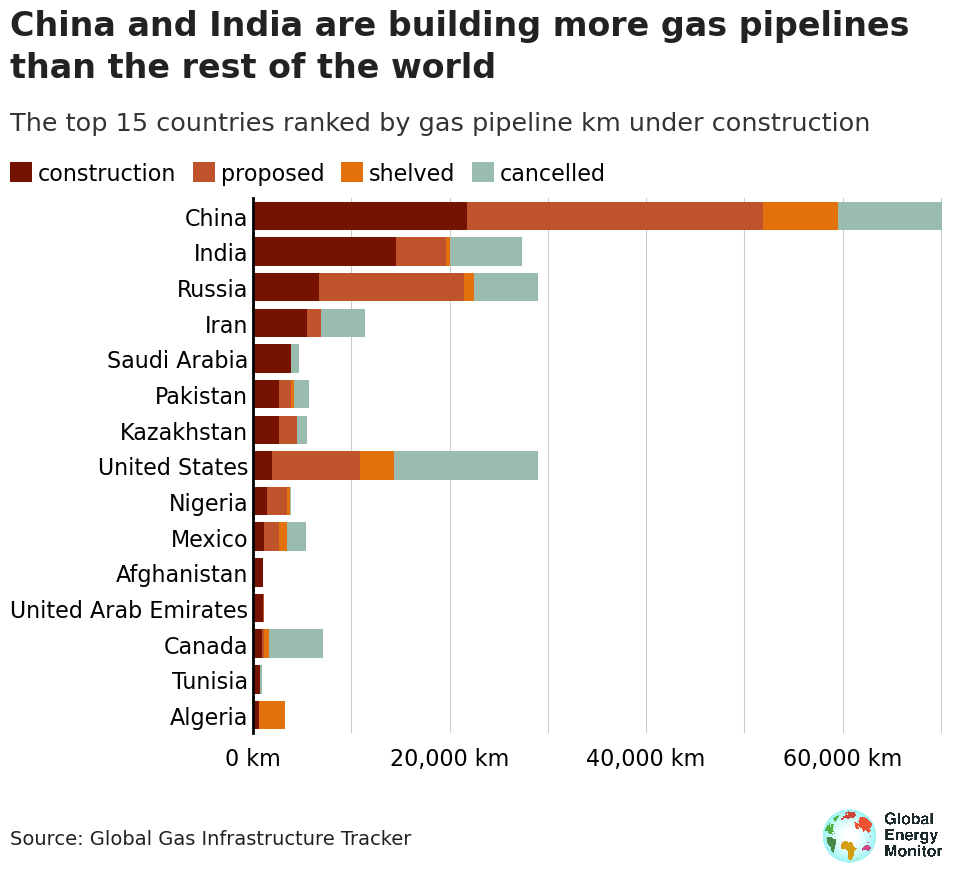

In [121]:
width_pixels = 640
height_pixels = 500
fig = mp.figure(figsize=(width_pixels/72, height_pixels/72))
fig.canvas.draw()
nbars=15

country_order = km_by_country_df.sort_values('construction', ascending=False).index[:nbars][::-1]

ax = fig.add_subplot(111)

bar_height = 0.8

ax.barh(numpy.arange(nbars), 
        km_by_country_df.loc[country_order]['construction'].values, 
        facecolor=tracker_construction,#solar_orange, 
        label='construction',
        height=bar_height)

ax.barh(numpy.arange(nbars), 
        km_by_country_df.loc[country_order]['proposed'].values, 
        left=km_by_country_df.loc[country_order]['construction'].values, 
        facecolor=tracker_proposed,
        label='proposed',
        height=bar_height)

ax.barh(numpy.arange(nbars), 
        km_by_country_df.loc[country_order]['shelved'].values, 
        left=km_by_country_df.loc[country_order][['proposed','construction']].sum(axis=1).values, 
        facecolor=tracker_shelved,
        label='shelved',
        height=bar_height)

ax.barh(numpy.arange(nbars), 
        km_by_country_df.loc[country_order]['cancelled'].values, 
        left=km_by_country_df.loc[country_order][['proposed','construction','shelved']].sum(axis=1).values, 
        facecolor=tracker_cancelled,
        label='cancelled',
        height=bar_height)

# FORMATTING
ax.tick_params(labelsize=base_size)
ax.tick_params(which='both',size=0)
ax.tick_params('x', pad=10)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_linewidth(2)

# format axis to have proper units and commas in thousands place
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f} km'))
ax.set_xlim(0,70100)
ax.set_ylim(-.5,nbars-.5)
ax.set_xticks([0,20000,40000,60000])

ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2)) # 2 for dividing major ticks into 2
ax.xaxis.grid(which='both',
              color=color_grid)

ax.set_axisbelow(True)
ax.set_yticks(numpy.arange(nbars))
ax.set_yticklabels(country_order)

# add titles, first get the location of the yaxis labels so they can line up exactly
# call it "x_locatio"
bbox = ax.get_tightbbox() #ax.get_yticklabels()[-1].get_window_extent()
x_location,_ = ax.transAxes.inverted().transform([bbox.x0, bbox.y0])
legend = ax.legend(fontsize=base_size,
          frameon=False,
          loc='lower left',
          bbox_to_anchor=(x_location,1.025),
          bbox_transform=ax.transAxes,
          handlelength=1,
          handleheight=1,
          ncols=4,
          borderpad=0,
          borderaxespad=0,
          columnspacing=0.75,
          handletextpad=0.25)

# now get tight bbox again for further placement AFTER legend is added
bbox = legend.get_tightbbox(renderer=fig.canvas.renderer)
x_location,y_location = ax.transAxes.inverted().transform([bbox.x0, bbox.y1])
ax.text(s='The top 15 countries ranked by gas pipeline km under construction',
        size=base_size*1.15,
        color=color_subtitle,
        x=x_location,
        y=y_location+0.05,
        ha='left',
        va='bottom',
        weight=text_weight_normal,
        transform=ax.transAxes,
        linespacing=1.45,
        wrap=True)

bbox_with_subtitle = ax.get_tightbbox(renderer=fig.canvas.renderer)
x_location_subtitle,y_location_subtitle = ax.transAxes.inverted().transform([bbox_with_subtitle.x0, bbox_with_subtitle.y1])
ax.text(s='China and India are building more gas pipelines\nthan the rest of the world',
        size=base_size*1.5,
        color=color_title,
        x=x_location,
        y=y_location_subtitle+0.05,#1.2,
        ha='left',
        va='bottom',
        weight=text_weight_bold,
        transform=ax.transAxes,
        linespacing=1.35,
        wrap=False)

ax.text(s='Source: Global Gas Infrastructure Tracker',
        size=base_size*0.875,
        color=color_title,
        x=x_location,
        y=-0.22*450/height_pixels, # make sure the caption adjust appropriately relative to default height of 450
        ha='left',
        va='center',
        weight=text_weight_normal,
        transform=ax.transAxes,
        linespacing=1.2,
        wrap=False)

gem_logo = matplotlib.image.imread('/Users/baird/Dropbox/_git_ALL/_github-repos-gem/gemplot-python/data/gem_logo_padding.png')
logo_image_box = matplotlib.offsetbox.OffsetImage(gem_logo, zoom=0.035)
logo_annotation_box = matplotlib.offsetbox.AnnotationBbox(logo_image_box,
                                                          (1,0), # sets box alignment to lower right corder
                                                          xycoords='axes fraction',
                                                          box_alignment=(1.,2.15), 
                                                          frameon=False)
ax.add_artist(logo_annotation_box)

# mp.savefig('../figures/Figure02-gas-pipelines_top-20-countries-sorted-by-construction.png',
#           bbox_inches='tight',
#           transparent=False,
#           dpi=300)

# mp.savefig('../figures/Figure02-gas-pipelines_top-20-countries-sorted-by-construction.pdf',
#           bbox_inches='tight', 
#           transparent=False)

In [122]:
# ratio of China to India (how many times larger is km of Chinese pipelines than India?)
km_by_country_df.loc['China']['proposed+construction']/km_by_country_df.loc['India']['proposed+construction']

np.float64(2.644008346435118)

### count fraction of available capacity information

count

In [123]:
pipes_df_subset = pipes_df_orig.loc[(pipes_df_orig.Status.isin(['construction','proposed']))&
                                     (pipes_df_orig.Fuel=='Gas')]
pipes_df_subset.loc[~pipes_df_subset['CapacityBcm/y'].isna()].groupby('StartRegion')['CapacityBOEd'].size()
#pipes_df_subset.groupby('StartRegion')['CapacityBcm/y'].size()

StartRegion
Africa       11
Americas    163
Asia        282
Europe      108
Oceania      15
Name: CapacityBOEd, dtype: int64

fraction

In [124]:
pandas.options.display.float_format = '{:,.3f}'.format
pandas.DataFrame(pipes_df_subset.loc[
    ~pipes_df_subset['CapacityBcm/y'].isna()].groupby(
    'StartRegion')['CapacityBcm/y'].size()/pipes_df_subset.groupby(
    'StartRegion')['CapacityBOEd'].size()).sort_values(by=0, ascending=False)

,0
StartRegion,
Americas,0.896
Oceania,0.833
Asia,0.683
Europe,0.543
Africa,0.275


In [125]:
median_capacity = pipes_df_orig.loc[pipes_df_orig.Fuel=='Gas']['CapacityBcm/y'].median()

In [126]:
abs_dist_from_med_capacity = abs(pipes_df_orig.loc[pipes_df_orig.Fuel=='Gas']['CapacityBcm/y']-
                                 pipes_df_orig.loc[pipes_df_orig.Fuel=='Gas']['CapacityBcm/y'].median()).median()

In [127]:
pipes_df_orig['CapacityBcm/y'].mean()

np.float64(10.278172706245181)

In [128]:
pipes_df_orig['CapacityBcm/y'].std()

np.float64(120.89640477659115)

In [129]:
print(median_capacity)
print(abs_dist_from_med_capacity)

3.085
2.685


median capacity for a pipeline is about 4.14 bcm/y

median abs dist from the median is about 3.5.

# cost estimates (pipeline cost per km)

## pick out high and low quantiles

In [130]:
temp_df = pipes_df_orig.loc[(~pipes_df_orig.CostUSDPerKm.isnull())&
                            (pipes_df_orig.Fuel=='Gas')]
qlo_val = 0.025
qhi_val = 0.975

q_lo=temp_df['CostUSDPerKm'].quantile(qlo_val)
q_hi=temp_df['CostUSDPerKm'].quantile(qhi_val)
print(temp_df['CostUSDPerKm'].quantile(qlo_val))
print(temp_df['CostUSDPerKm'].quantile(qhi_val))

temp_df = temp_df.loc[temp_df['CostUSDPerKm'].between(q_lo, q_hi, inclusive='neither')]

140433.33332
19991836.013


In [131]:
# pull out only pipelines that have a KNOWN length AND a cost
country_ratios_with_length_and_cost_df = country_ratios_df.loc[(country_ratios_df['Fuel']=='Gas') & 
                                                               (country_ratios_df['CostUSDPerKm'].notna()) & 
                                                               (country_ratios_df['LengthKnownKmByCountry'].notna()) #&
                                                               #(country_ratios_df['LengthKnownKm']!=0) &
                                                               #(country_ratios_df['CostUSDPerKm']<10e6)
                                                              ]

country_ratios_with_length_and_cost_df = country_ratios_with_length_and_cost_df.loc[
    country_ratios_with_length_and_cost_df['CostUSDPerKm'].between(q_lo, q_hi, inclusive='neither')]
#country_ratios_with_length_and_cost_df = country_ratios_with_length_and_cost_df[~country_ratios_with_length_and_cost_df.ProjectID.isin(outliers_projectids)]

In [132]:
country_ratios_df.loc[(country_ratios_df['Fuel']=='Gas') & 
                    (country_ratios_df['CostUSDPerKm'].notna()) & 
                    (country_ratios_df['LengthKnownKmByCountry'].notna())].shape

(1407, 34)

In [133]:
country_ratios_df.loc[(country_ratios_df['Fuel']=='Gas')].shape

(4568, 34)

In [134]:
# 2024 fraction of costs
1034/4012

0.2577268195413759

In [135]:
# 2025 fraction of costs
1407/4568

0.3080122591943958

### global mean value

In [136]:
country_ratios_with_length_and_cost_df['CostUSDPerKm'].drop_duplicates().mean()

np.float64(2484624.5318189883)

### calculate regional costs

In [137]:
region_list

['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']

In [138]:
pipes_costs_region_df = pandas.DataFrame(0, index=region_list, columns=['CostUSDPerKm','DataPoints'])#,'NumberOfLengths'])

for region in region_list:
    country_ratios_region_df = country_ratios_with_length_and_cost_df.loc[country_ratios_with_length_and_cost_df['Region']==region,:]
    pipes_costs_region_df.loc[region,'CostUSDPerKm'] = country_ratios_region_df['CostUSDPerKm'].mean()
    pipes_costs_region_df.loc[region,'DataPoints'] = list(set(country_ratios_region_df['ProjectID'])).__len__()

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_87296/3912453063.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2665390.6871428574' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pipes_costs_region_df.loc[region,'CostUSDPerKm'] = country_ratios_region_df['CostUSDPerKm'].mean()


In [139]:
pipes_costs_subregion_df = pandas.DataFrame(0, index=subregion_list, columns=['CostUSDPerKm','DataPoints'])#,'NumberOfLengths'])

for subregion in subregion_list:
    country_ratios_subregion_df = country_ratios_with_length_and_cost_df.loc[country_ratios_with_length_and_cost_df['SubRegion']==subregion,:]
    pipes_costs_subregion_df.loc[subregion,'CostUSDPerKm'] = country_ratios_subregion_df['CostUSDPerKm'].mean()
    pipes_costs_subregion_df.loc[subregion,'DataPoints'] = list(set(country_ratios_subregion_df['ProjectID'])).__len__()

# for subregions with no data, inherit from the REGIONAL cost
for idx,row in pipes_costs_subregion_df.loc[pipes_costs_subregion_df.CostUSDPerKm.isnull()].iterrows():
    #print(pipes_costs_subregion_df.loc[idx,'CostUSDPerKm'])
    which_region = idx
    pipes_costs_subregion_df.loc[idx,'CostUSDPerKm'] = pipes_costs_region_df.loc[dict_subregion_region[which_region],'CostUSDPerKm']

pipes_costs_subregion_df.sort_values('CostUSDPerKm', ascending=False)

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_87296/3870605072.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2797110.2678947365' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pipes_costs_subregion_df.loc[subregion,'CostUSDPerKm'] = country_ratios_subregion_df['CostUSDPerKm'].mean()


,CostUSDPerKm,DataPoints
Northern America,"5,211,134.145",207
Western Europe,"3,874,664.339",34
Western Asia,"3,809,438.258",62
Sub-Saharan Africa,"3,779,198.981",8
Northern Europe,"3,682,665.716",18
Southern Europe,"3,027,093.029",61
Eastern Europe,"2,995,288.656",89
Central Asia,"2,888,230.066",28
Australia and New Zealand,"2,797,110.268",19
Latin America and the Caribbean,"2,775,603.946",66


In [140]:
pipes_costs_region_df

,CostUSDPerKm,DataPoints
Africa,"2,665,390.687",48
Americas,"4,572,446.156",267
Asia,"1,803,157.944",663
Europe,"3,198,510.899",186
Oceania,"2,681,148.570",19


In [141]:
country_ratios_region_df['CostUSDPerKm'].mean()

np.float64(2681148.5705)

In [142]:
pandas.options.display.float_format = '{:,.3f}'.format
temp_df = pipes_costs_region_df.copy()
temp_df['CostUSDPerKm'] = temp_df['CostUSDPerKm']/1e6
temp_df.sort_values('CostUSDPerKm', ascending=False)#.loc[region]['CostUSDPerKm']

,CostUSDPerKm,DataPoints
Americas,4.572,267
Europe,3.199,186
Oceania,2.681,19
Africa,2.665,48
Asia,1.803,663


In [143]:
pandas.options.display.float_format = '{:,.3f}'.format
temp_df = pipes_costs_subregion_df.copy()
temp_df['CostUSDPerKm'] = temp_df['CostUSDPerKm']/1e6
temp_df.sort_values('CostUSDPerKm', ascending=False)#.loc[region]['CostUSDPerKm']

,CostUSDPerKm,DataPoints
Northern America,5.211,207
Western Europe,3.875,34
Western Asia,3.809,62
Sub-Saharan Africa,3.779,8
Northern Europe,3.683,18
Southern Europe,3.027,61
Eastern Europe,2.995,89
Central Asia,2.888,28
Australia and New Zealand,2.797,19
Latin America and the Caribbean,2.776,66


# tables etc.

## table for stranded asset calculations

## country-level capex estimates

In [144]:
pipes_costs_region_df.sort_values('CostUSDPerKm', ascending=False)

,CostUSDPerKm,DataPoints
Americas,"4,572,446.156",267
Europe,"3,198,510.899",186
Oceania,"2,681,148.570",19
Africa,"2,665,390.687",48
Asia,"1,803,157.944",663


add a cost USD estimate column and estimate costs based on region and km by country

In [145]:
pipes_costs_subregion_df

,CostUSDPerKm,DataPoints
Australia and New Zealand,"2,797,110.268",19
Central Asia,"2,888,230.066",28
Eastern Asia,"1,432,334.204",551
Eastern Europe,"2,995,288.656",89
Latin America and the Caribbean,"2,775,603.946",66
Melanesia,"477,876.320",1
Micronesia,"2,681,148.570",0
Northern Africa,"2,188,044.276",42
Northern America,"5,211,134.145",207
Northern Europe,"3,682,665.716",18


In [147]:
country_ratios_df.reset_index(drop=True, inplace=True)
country_ratios_df.loc[:,'CostUSDEstimate'] = numpy.nan

for idx,row in country_ratios_df.iterrows():
    # calculate cost
    cntry = row.Country
    #region = row.Region
    subregion = row.SubRegion
    km_by_cntry = row.LengthKnownKmByCountry
    #country_ratios_df.loc[idx,'CostUSDEstimate'] = pipes_costs_region_df.loc[region, 'CostUSDPerKm'] * km_by_cntry
    country_ratios_df.loc[idx,'CostUSDEstimate'] = pipes_costs_subregion_df.loc[subregion, 'CostUSDPerKm'] * km_by_cntry

# replace any known costs now
country_ratios_df.loc[(~country_ratios_df.LengthKnownKmByCountry.isna())&
                      (~country_ratios_df.CostUSDPerKm.isna()),'CostUSDEstimate'] = \
country_ratios_df.loc[(~country_ratios_df.LengthKnownKmByCountry.isna())&
                      (~country_ratios_df.CostUSDPerKm.isna()), 'LengthKnownKmByCountry'] * \
country_ratios_df.loc[(~country_ratios_df.LengthKnownKmByCountry.isna())&
                      (~country_ratios_df.CostUSDPerKm.isna()), 'CostUSDPerKm']

In [148]:
country_ratios_df.SubRegion.unique()

array(['Northern America', 'Latin America and the Caribbean',
       'Northern Africa', 'Western Asia', 'Sub-Saharan Africa',
       'Southern Europe', 'Southern Asia', 'Western Europe',
       'Australia and New Zealand', 'Eastern Europe', 'Central Asia',
       'Eastern Asia', 'Northern Europe', 'South-eastern Asia',
       'Melanesia'], dtype=object)

In [149]:
capex_by_country_df = pandas.DataFrame(columns=status_list, index=multiindex_region_subregion_country)
capex_by_region_df = pandas.DataFrame(columns=status_list, index=region_list)
capex_by_subregion_df = pandas.DataFrame(columns=status_list, index=multiindex_region_subregion)

print('===country-level calculations===')
for status in status_list:
    print(status)
    country_ratios_df_status = country_ratios_df.loc[country_ratios_df.Status==status]
    country_ratios_df_status = country_ratios_df_status.loc[~country_ratios_df_status.SubRegion.isnull()]
    capex_by_country_df[status] = country_ratios_df_status.groupby(['Region','SubRegion','Country'])['CostUSDEstimate'].sum()/1e9
    capex_by_region_df[status] = country_ratios_df_status.groupby('Region')['CostUSDEstimate'].sum()/1e9
    capex_by_subregion_df[status] = country_ratios_df_status.groupby(['Region','SubRegion'])['CostUSDEstimate'].sum()/1e9

# # fill NaN with 0.0
capex_by_region_df = capex_by_region_df.fillna(0)
capex_by_country_df = capex_by_country_df.fillna(0)
capex_by_subregion_df = capex_by_subregion_df.fillna(0)

capex_by_region_df['proposed+construction'] = capex_by_region_df[['proposed','construction']].sum(axis=1)
capex_by_region_df = capex_by_region_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
capex_by_region_df.loc['Total',:] = capex_by_region_df.sum(axis=0).values

capex_by_country_df['proposed+construction'] = capex_by_country_df[['proposed','construction']].sum(axis=1)
capex_by_country_df = capex_by_country_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
#capex_by_country_df.sort_values('construction', ascending=False, inplace=True)
capex_by_country_df.loc['Total',:] = capex_by_country_df.sum(axis=0).values
capex_by_country_df = capex_by_country_df.loc[~(capex_by_country_df==0).all(axis=1)]
capex_by_country_df = capex_by_country_df.replace(0,'')

capex_by_subregion_df['proposed+construction'] = capex_by_subregion_df[['proposed','construction']].sum(axis=1)
#capex_by_country_df.sort_values(by='proposed+construction', inplace=True)
capex_by_subregion_df = capex_by_subregion_df[['proposed', 'construction', 'proposed+construction', 'shelved', 'cancelled', 'operating', 'idle', 'mothballed', 'retired']]
#capex_by_subregion_df.sort_values('construction', ascending=False, inplace=True)
capex_by_subregion_df.loc['Total',:] = capex_by_subregion_df.sum(axis=0).values

===country-level calculations===
proposed
construction
shelved
cancelled
operating
idle
mothballed
retired


In [150]:
capex_by_country_df

proposed  \
Region  SubRegion                 Country                                     
Africa  Northern Africa           Algeria                                     
                                  Egypt                               1.156   
                                  Libya                               2.434   
                                  Morocco                             6.379   
                                  Overlapping claim: Egypt / Libya            
...                                                                     ...   
Europe  Western Europe            Switzerland                                 
Oceania Australia and New Zealand Australia                          19.607   
                                  New Zealand                                 
        Melanesia                 Papua New Guinea                    0.153   
Total                                                               488.887   

                                                                   construction  \
Region  SubRegion                 Country                                         
Africa  Northern Africa           Algeria                                 3.289   
                                  Egypt                                   1.223   
                                  Libya                                   0.676   
                                  Morocco                                         
                                  Overlapping claim: Egypt / Libya                
...                                                                         ...   
Europe  Western Europe            Switzerland                                     
Oceania Australia and New Zealand Australia                               0.084   
                                  New Zealand                                     
        Melanesia                 Papua New Guinea                                
Total                                                                   225.745   

                                                                   proposed+construction  \
Region  SubRegion                 Country                                                  
Africa  Northern Africa           Algeria                                          3.289   
                                  Egypt                                            2.379   
                                  Libya                                            3.110   
                                  Morocco                                          6.379   
                                  Overlapping claim: Egypt / Libya                         
...                                                                                  ...   
Europe  Western Europe            Switzerland                                              
Oceania Australia and New Zealand Australia                                       19.691   
                                  New Zealand                                              
        Melanesia                 Papua New Guinea                                 0.153   
Total                                                                            714.632   

                                                                   shelved  \
Region  SubRegion                 Country                                    
Africa  Northern Africa           Algeria                            8.444   
                                  Egypt                                      
                                  Libya                                      
                                  Morocco                                    
                                  Overlapping claim: Egypt / Libya           
...                                                                    ...   
Europe  Western Europe            Switzerland                                
Oceania Australia and New Zealand Australia                 

In [151]:
capex_by_region_df.replace(0,'')

,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired
Africa,60.344,9.705,70.048,23.623,11.295,211.952,,,0.013
Americas,136.931,29.702,166.633,63.779,340.683,"3,318.003",1.794,9.721,33.632
Asia,170.926,162.709,333.635,36.230,117.972,838.041,4.556,13.009,16.355
Europe,100.926,23.546,124.472,16.921,71.752,965.333,13.649,38.188,17.003
Oceania,19.760,0.084,19.844,5.533,17.860,96.135,1.410,0.243,0.617
Total,488.887,225.745,714.632,146.086,559.562,"5,429.464",21.409,61.161,67.621


In [152]:
capex_by_subregion_df.index = capex_by_subregion_df.index.set_names(['Region','Subregion'])
capex_by_subregion_df.replace(0,'')

proposed construction  \
Region   Subregion                                               
Africa   Northern Africa                   13.701        6.335   
         Sub-Saharan Africa                46.643        3.370   
Americas Latin America and the Caribbean   70.047        5.464   
         Northern America                  66.883       24.238   
Asia     Central Asia                      13.813        8.309   
         Eastern Asia                      62.261       40.680   
         South-eastern Asia                14.786        0.400   
         Southern Asia                     28.038       59.573   
         Western Asia                      52.028       53.746   
Europe   Eastern Europe                    63.718       20.928   
         Northern Europe                    1.160        0.071   
         Southern Europe                   31.494        1.207   
         Western Europe                     4.554        1.340   
Oceania  Australia and New Zealand         19.607        0.084   
         Melanesia                          0.153                
         Micronesia                                              
         Polynesia                                               
Total                                     488.887      225.745   

                                         proposed+construction shelved  \
Region   Subregion                                                       
Africa   Northern Africa                                20.035   8.580   
         Sub-Saharan Africa                             50.013  15.043   
Americas Latin America and the Caribbean                75.511  11.742   
         Northern America                               91.122  52.037   
Asia     Central Asia                                   22.123   6.702   
         Eastern Asia                                  102.942  11.964   
         South-eastern Asia                             15.186   9.894   
         Southern Asia                                  87.612   3.081   
         Western Asia                                  105.773   4.588   
Europe   Eastern Europe                                 84.646   6.898   
         Northern Europe                                 1.231   0.028   
         Southern Europe                                32.701   6.699   
         Western Europe                                  5.894   3.296   
Oceania  Australia and New Zealand                      19.691   5.533   
         Melanesia                                       0.153           
         Micronesia                                                      
         Polynesia                                                       
Total                                                  714.632 146.086   

                                         cancelled operating   idle  \
Region   Subregion                                                    
Africa   Northern Africa                     1.627   157.229          
         Sub-Saharan Africa                  9.669    54.723          
Americas Latin America and the Caribbean    15.053   275.352  1.218   
         Northern America                  325.630 3,042.651  0.577   
Asia     Central Asia                        3.174   103.963          
         Eastern Asia                       25.166   282.962  0.066   
         South-eastern Asia                  6.042    45.248  0.082   
         Southern Asia                      39.967   146.176          
         Western Asia                       43.623   259.692  4.408   
Europe   Eastern Europe                     39.005   659.065 10.660   
         Northern Europe                     3.696   109.156  2.584   
         Southern Europe                    19.128    78.539  0.372   
         Western Europe                      9.923   118.574  0.032   
Oceania  Australia and New Zealand          17.247    94.444  1.410   
         Melanesia                           0.612     1.691          
         Micronesia             

In [153]:
capex_by_country_df.to_excel('capex-by-country.xlsx')
capex_by_country_df.tail()

proposed construction  \
Region  SubRegion                 Country                                  
Europe  Western Europe            Switzerland                              
Oceania Australia and New Zealand Australia          19.607        0.084   
                                  New Zealand                              
        Melanesia                 Papua New Guinea    0.153                
Total                                               488.887      225.745   

                                                   proposed+construction  \
Region  SubRegion                 Country                                  
Europe  Western Europe            Switzerland                              
Oceania Australia and New Zealand Australia                       19.691   
                                  New Zealand                              
        Melanesia                 Papua New Guinea                 0.153   
Total                                                            714.632   

                                                   shelved cancelled  \
Region  SubRegion                 Country                              
Europe  Western Europe            Switzerland                  0.276   
Oceania Australia and New Zealand Australia          5.533    17.247   
                                  New Zealand                          
        Melanesia                 Papua New Guinea             0.612   
Total                                              146.086   559.562   

                                                   operating   idle  \
Region  SubRegion                 Country                             
Europe  Western Europe            Switzerland          1.657          
Oceania Australia and New Zealand Australia           86.655  1.410   
                                  New Zealand          7.789          
        Melanesia                 Papua New Guinea     1.691          
Total                                              5,429.464 21.409   

                                                   mothballed retired  
Region  SubRegion                 Country                              
Europe  Western Europe            Switzerland                          
Oceania Australia and New Zealand Australia             0.243   0.617  
                                  New Zealand                          
        Melanesia                 Papua New Guinea                     
Total                                                  61.161  67.621

## capex data - 15 leading countries by construction

In [72]:
country_order

Index(['Poland', 'Algeria', 'Italy', 'Argentina', 'Afghanistan',
       'United States', 'Nigeria', 'Mexico', 'Canada', 'Pakistan', 'Russia',
       'Iran', 'Saudi Arabia', 'India', 'China'],
      dtype='object')

In [73]:
km_by_country_df

,Region,Subregion,proposed,construction,proposed+construction,shelved,cancelled,operating,idle,mothballed,retired
China,Asia,Eastern Asia,"40,740.840","27,951.550","68,692.390","6,232.160","3,059.510","139,358.420",0.000,127.530,114.400
Russia,Europe,Eastern Europe,"17,404.710","4,169.630","21,574.340","1,194.050","6,316.520","115,339.700",414.270,"1,411.910","2,263.580"
India,Asia,Southern Asia,"5,358.120","14,445.610","19,803.730","1,310.000","6,211.050","18,914.160",0.000,0.000,0.000
Australia,Oceania,Australia and New Zealand,"9,856.640",4.300,"9,860.940","3,726.220","7,214.680","29,524.340",0.000,0.000,0.000
United States,Americas,Northern America,"7,406.060","1,396.420","8,802.480","3,736.660","14,090.730","339,176.030",110.630,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
Liechtenstein,Europe,Western Europe,0.000,0.000,0.000,0.000,1.900,1.290,0.000,0.000,0.000
Bolivia,Americas,Latin America and the Caribbean,0.000,0.000,0.000,825.020,0.000,"2,525.460",0.000,0.000,0.000
Brunei,Asia,South-eastern Asia,0.000,0.000,0.000,0.000,0.000,39.000,0.000,0.000,0.000
"Joint regime area (Peru, Ecuador)",Americas,Latin America and the Caribbean,0.000,0.000,0.000,0.000,0.000,13.280,0.000,0.000,0.000


In [79]:
nbars = 15
country_order = km_by_country_df.sort_values('construction', ascending=False).index.tolist()[:nbars]
#capex_by_country_df.loc[country_order]

## print out country-level stranded assets for report discussion

## in-dev for each country in list

# numbers for report

## amount already being constructed

In [82]:
# fraction of pipelines under construction compared to all in development
# this number is different from below because it's skipping some pipelines
km_by_country_total = km_by_country_df.sum(axis=0)
km_by_country_total['construction']/km_by_country_total['proposed+construction']

np.float64(0.32570253992258263)

## total pipeline km in dev

In [87]:
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Oil')&
                  (pipes_df_orig.Status.isin(['proposed','construction']))]['LengthMergedKm'].sum()

np.float64(29108.849999999995)

## top 10 pipelines

## biggest pipelines that went into construction in 2022/2023

In [ ]:
biggest_pipeline_names_table = pandas.DataFrame(pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                                                                  (pipes_df_orig.Status.isin(['construction','operating']))&
                                                                  (pipes_df_orig.constructionYear.isin([2022,2023]))].groupby(['PipelineName','Status','Wiki'])['LengthMergedKm'].sum(min_count=1).sort_values(ascending=False)[:19])

biggest_pipeline_names_table

## biggest pipeline projects by name in China, rather than individual ProjectID

In [ ]:
biggest_pipeline_names_table = pandas.DataFrame(pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                                                                  (pipes_df_orig.Status.isin(['proposed','construction']))&
                                                                  (pipes_df_orig.Countries.str.contains('China'))].groupby(['PipelineName','Status','Wiki'])['LengthMergedKm'].sum(min_count=1).sort_values(ascending=False)[:19])

biggest_pipeline_names_table

In [ ]:
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                (pipes_df_orig.Status.isin(['construction']))&
                (pipes_df_orig.Countries.str.contains('China'))].shape

In [ ]:
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                (pipes_df_orig.Status.isin(['construction']))&
                (pipes_df_orig.Countries.str.contains('China'))].LengthMergedKm.mean()

## km of pipeline with 2023, 2024 start years

In [ ]:
# for the key points
print(pipes_indev_startyear.loc['construction',2023],
      pipes_indev_startyear.loc['construction',2024])

print(pipes_indev_startyear.loc['proposed',2023],
      pipes_indev_startyear.loc['proposed',2024])

## km of gas pipelines globally in development

note this doesn't match up exactly with regional length calculations

In [ ]:
pipes_df_calc = pipes_df_orig.copy()
pipes_df_calc.replace('--',numpy.nan,inplace=True)
pipes_df_calc[(pipes_df_calc['Status'].isin(['proposed','construction'])) &
        (pipes_df_calc['Fuel']=='Gas')]['LengthMergedKm'].sum()

In [ ]:
regional_km_sums_df = pandas.DataFrame(index=region_list, columns=status_list)

for status in status_list:
    regional_km_sums_df[status] = pipes_df_calc[(pipes_df_calc['Fuel']=='Gas') &
                                                (pipes_df_calc['Status']==status)].groupby('StartRegion')['LengthMergedKm'].sum()

regional_km_sums_df['P+C'] = regional_km_sums_df[['proposed','construction']].sum(axis=1)
total_row = regional_km_sums_df.sum(axis=0)
total_row.name = 'Total'
#regional_km_sums_df.append(total_row)

## country shares analysis

In [ ]:
country_ratios_df[(country_ratios_df['Status'].isin(['proposed','construction'])) &
               (country_ratios_df['Fuel']=='Oil')]['MergedKmByCountry'].sum()

## num in dev globally, whether capacity expansions or not

In [ ]:
print("capacity expansion projects:",
    pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                  (pipes_df_orig.Status.isin(['proposed','construction']))&
                  (pipes_df_orig.RouteType.isin(['Capacity expansion only','Bidirectionality upgrade only']))].shape)

print("non-zero length projects:",
      pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                  (pipes_df_orig.Status.isin(['proposed','construction']))&
                  (~pipes_df_orig.RouteType.isin(['Capacity expansion only','Bidirectionality upgrade only']))].shape)

In [ ]:
print(pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                  (pipes_df_orig.Status.isin(['proposed','construction']))&
                  (pipes_df_orig.RouteType.isin(['Capacity expansion only','Bidirectionality upgrade only']))]['CapacityBOEd'])

print(pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                  (pipes_df_orig.Status.isin(['proposed','construction']))&
                  (pipes_df_orig.RouteType.isin(['Capacity expansion only','Bidirectionality upgrade only']))][['Countries','CapacityBOEd']])

# delay/difficulty to build analysis

### delays in 2023

In [ ]:
# how many have a start year of 2023 but haven't begun?
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                    (pipes_df_orig.StartYearEarliest==2023)].groupby(['Status'])['LengthMergedKm'].sum()

In [ ]:
# how many have a start year of 2023 but haven't begun?
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
                    (pipes_df_orig.StartYearEarliest==2023)].groupby(['Status','StartRegion'])['LengthMergedKm'].sum()

### timeline of pipeline completion

In [ ]:
# timeline of pipeline completion?
# need both proposal year and needs to be operational and have a start year
pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
    (pipes_df_orig.Status=='operating')&
    (~pipes_df_orig.StartYearEarliest.isnull())&
    (pipes_df_orig.ProposalYear!='')]

In [ ]:
pipes_df_gas_with_completion_data = pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
    (pipes_df_orig.Status=='operating')&
    (~pipes_df_orig.StartYearEarliest.isnull())&
    (pipes_df_orig.ProposalYear!='')&
    (pipes_df_orig.ProposalYear!=pipes_df_orig.StartYearEarliest)]

In [ ]:
pipes_df_gas_with_completion_data.shape

In [ ]:
numpy.array(pipes_df_gas_with_completion_data.StartYearEarliest-pipes_df_gas_with_completion_data.ProposalYear).mean()

In [ ]:
# mean rate of construction (km of pipeline per year)
numpy.array(pipes_df_gas_with_completion_data.LengthMergedKm/(pipes_df_gas_with_completion_data.StartYearEarliest-pipes_df_gas_with_completion_data.ProposalYear)).mean()

In [ ]:
numpy.array(pipes_df_gas_with_completion_data.StartYearEarliest-pipes_df_gas_with_completion_data.ProposalYear)

In [ ]:
mp.hist(x=numpy.array(pipes_df_gas_with_completion_data.LengthMergedKm/(pipes_df_gas_with_completion_data.StartYearEarliest-pipes_df_gas_with_completion_data.ProposalYear)),
       bins=50)

### how long are shelved pipelines hanging around?

In [ ]:
# we care about whether it's shelved, and when it was proposed
pipes_df_gas_with_shelved_data = pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
    (pipes_df_orig.Status=='shelved')&
    #(pipes_df_orig.shelvedYear!='')&
    #(~pipes_df_orig.StartYearEarliest.isnull())&
    (pipes_df_orig.ProposalYear!='')]

In [ ]:
numpy.array(2023-pipes_df_gas_with_shelved_data.ProposalYear).mean()

In [ ]:
# we care about whether it's shelved, and when it was proposed
pipes_df_gas_with_shelved_data = pipes_df_orig.loc[(pipes_df_orig.Fuel=='Gas')&
    (pipes_df_orig.Status=='shelved')&
    (pipes_df_orig.shelvedYear!='')&
    #(~pipes_df_orig.StartYearEarliest.isnull())&
    (pipes_df_orig.ProposalYear!='')]

In [ ]:
# about 22 projects right now that are marked shelved AND have a proposal year
pipes_df_gas_with_shelved_data.shelvedYear-pipes_df_gas_with_shelved_data.ProposalYear

In [ ]:
# about 22 projects right now that are marked shelved AND have a proposal year
numpy.array(pipes_df_gas_with_shelved_data.shelvedYear-pipes_df_gas_with_shelved_data.ProposalYear).mean()

# China, India vs rest of world

In [ ]:
km_by_country_df.loc[['China','India']].construction.sum()/km_by_country_df.construction.sum()

In [ ]:
km_by_country_df.loc[['China','India']]['proposed+construction'].sum()/km_by_country_df['proposed+construction'].sum()

In [ ]:
km_by_country_df.loc[['China','India']].construction.sum()

In [ ]:
km_by_country_df.construction.sum()

In [ ]:
km_by_country_df.construction.sum()-30313-15283

In [ ]:
km_by_country_df.loc['China'].construction

In [401]:
km_by_country_df.loc['India'].construction

15283.0

In [394]:
km_by_country_df.loc[['China','India']].construction.sum()

45596.36

In [395]:
km_by_country_df.drop(['China','India']).construction.sum()#loc[[~'China','India']]

24069.36

In [385]:
km_by_country_df.head()

,Region,Subregion,Proposed,Construction,Proposed+Construction,Shelved,Cancelled,Operating,Idle,Mothballed,Retired
China,Asia,Eastern Asia,"36,090.210","30,313.360","66,403.570",731.110,"1,462.870","122,333.770",0.000,0.000,114.400
Russia,Europe,Eastern Europe,"18,444.520","2,901.930","21,346.450","1,246.650","4,904.560","113,072.590",414.270,"1,177.300","2,000.580"
India,Asia,Southern Asia,"5,573.680","15,283.000","20,856.680","1,055.000","4,671.050","19,019.420",0.000,0.000,0.000
Australia,Oceania,Australia and New Zealand,"9,856.640",4.300,"9,860.940","3,726.220","7,214.680","29,524.310",0.000,0.000,0.000
United States,Americas,Northern America,"7,237.220","1,448.000","8,685.220","3,374.580","14,090.540","340,248.820",50.000,0.000,0.000
